# 🧪 CartPole-v1: Actor-Critic (A2CC) Research Lab Notebook

This notebook contains a complete, from-scratch implementation of a Vanilla online 1-step Actor-Critic agent in PyTorch, evaluated on Gymnasium's `CartPole-v1` environment. 

Following the core implementation, we conduct several deep RL research experiments to study the training dynamics, critic convergence, TD error distribution, and typical failure modes of Actor-Critic architectures.

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Network Architectures

We implement the Actor and Critic as separate neural networks. The Actor maps state observations to action probability logits, and the Critic maps state observations to a scalar state-value estimate $V(s)$.

In [2]:
class ActorNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(ActorNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, action_dim)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        logits = self.fc2(x)
        return logits

class CriticNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super(CriticNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        
    def forward(self, state):
        x = F.relu(self.fc1(state))
        value = self.fc2(x)
        return value

## 2. Vanilla Actor-Critic (A2CC) Implementation

We train the agent online using 1-step temporal difference (TD) updates. 
At each step $t$:
1. Compute TD target: $y_t = r_t + \gamma V(s_{t+1})$
2. Compute TD error / Advantage: $\delta_t = y_t - V(s_t)$
3. Optimize Critic by minimizing Mean Squared Error: $\mathcal{L}_{critic} = \delta_t^2$
4. Optimize Actor by maximizing expected return with an entropy exploration bonus: $\mathcal{L}_{actor} = -\log \pi(a_t|s_t) \delta_t - \beta \mathcal{H}(\pi(s_t))$

In [ ]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

# Hyperparameters
lr_actor = 1e-3
lr_critic = 3e-3
gamma = 0.99
entropy_coef = 0.01  # Exploration helper
num_episodes = 800

actor = ActorNetwork(state_dim, action_dim).to(device)
critic = CriticNetwork(state_dim).to(device)

actor_optimizer = optim.Adam(actor.parameters(), lr=lr_actor)
critic_optimizer = optim.Adam(critic.parameters(), lr=lr_critic)

# Experiment Tracking Lists
episode_rewards = []
critic_loss_history = []
td_error_history = []

print("Starting Vanilla Actor-Critic training...")
for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        # Convert state array to tensor and unsqueeze to handle batch shape [1, state_dim]
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        # Choose action using policy
        logits = actor(state_tensor)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        
        # Take action in environment
        next_state, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0).to(device)
        
        # Value estimates
        value = critic(state_tensor)
        with torch.no_grad():
            next_value = critic(next_state_tensor) if not done else torch.tensor([[0.0]]).to(device)
            
        # Compute TD Target and TD Error
        td_target = reward + gamma * next_value
        td_error = td_target - value
        
        # Record TD error for research audit
        td_error_history.append(td_error.detach().cpu().item())
        
        # Loss Functions
        # Note: We detach td_error from gradient computation when updating the actor
        actor_loss = -log_prob * td_error.detach() - entropy_coef * entropy
        critic_loss = F.mse_loss(value, td_target)
        
        # Record critic loss
        critic_loss_history.append(critic_loss.item())
        
        # Updates
        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()
        
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()
        
        state = next_state
        total_reward += reward
        
    episode_rewards.append(total_reward)
    
    if (episode + 1) % 50 == 0:
        recent_avg = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:03d} | 50-Episode Mean Reward: {recent_avg:.1f}")
        if recent_avg >= 475.0:
            print(f"Solved at episode {episode+1}!")
            break

env.close()

Starting Vanilla Actor-Critic training...
Episode 050 | 50-Episode Mean Reward: 15.2
Episode 100 | 50-Episode Mean Reward: 39.0
Episode 150 | 50-Episode Mean Reward: 60.8
Episode 200 | 50-Episode Mean Reward: 146.6
Episode 250 | 50-Episode Mean Reward: 186.1
Episode 300 | 50-Episode Mean Reward: 140.0
Episode 350 | 50-Episode Mean Reward: 111.4
Episode 400 | 50-Episode Mean Reward: 130.5
Episode 450 | 50-Episode Mean Reward: 148.9
Episode 500 | 50-Episode Mean Reward: 142.2
Episode 550 | 50-Episode Mean Reward: 169.1
Episode 600 | 50-Episode Mean Reward: 9.1
Episode 650 | 50-Episode Mean Reward: 9.4
Episode 700 | 50-Episode Mean Reward: 9.5
Episode 750 | 50-Episode Mean Reward: 9.3
Episode 800 | 50-Episode Mean Reward: 9.6


# EXPERIMENT 1 — Reward Learning Analysis

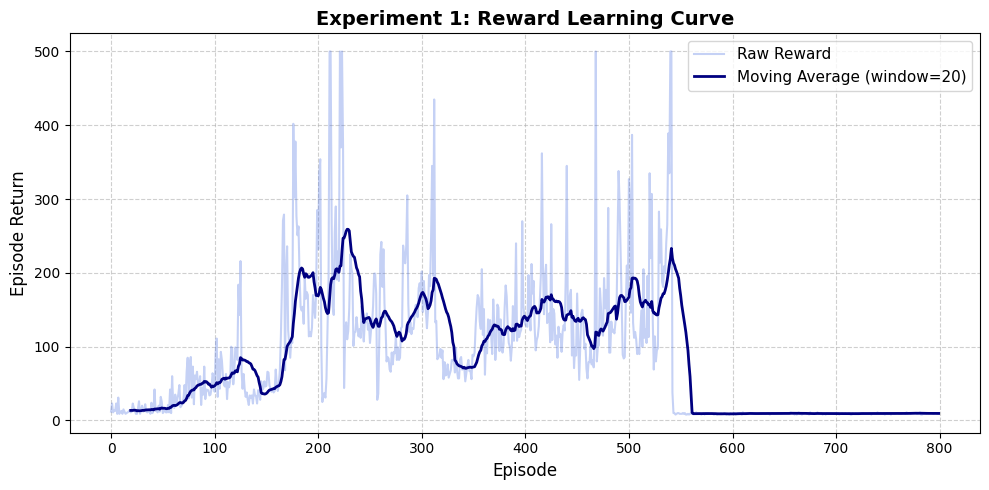

Final average reward over last 20 episodes: 9.55


In [4]:
def plot_reward_curves(rewards, window=20):
    raw = np.array(rewards)
    moving_avg = np.convolve(raw, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    plt.plot(raw, alpha=0.3, color='royalblue', label='Raw Reward')
    plt.plot(np.arange(window-1, len(raw)), moving_avg, color='navy', linewidth=2, label=f'Moving Average (window={window})')
    
    plt.title("Experiment 1: Reward Learning Curve", fontsize=14, fontweight='bold')
    plt.xlabel("Episode", fontsize=12)
    plt.ylabel("Episode Return", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()
    
    final_avg = np.mean(raw[-window:]) if len(raw) >= window else np.mean(raw)
    print(f"Final average reward over last {min(window, len(raw))} episodes: {final_avg:.2f}")

plot_reward_curves(episode_rewards)

### Research Audit: Reward Curves Interpretation

- **What reward curves indicate**: They show the trajectory of the policy's competence. Rising returns indicate the policy is successfully shifting probability mass toward higher-yielding action sequences.
- **What convergence means**: True convergence is characterized by the moving average plateauing near the maximum environment threshold (500 for CartPole-v1) with a corresponding decrease in raw return variance.
- **What instability means**: If the curves rise rapidly and then collapse, it signifies policy divergence. In online Actor-Critic, this is usually caused by the policy changing too quickly, rendering the Critic's older value predictions (which baseline the policy updates) obsolete and incorrect.

# EXPERIMENT 2 — Critic Learning Analysis

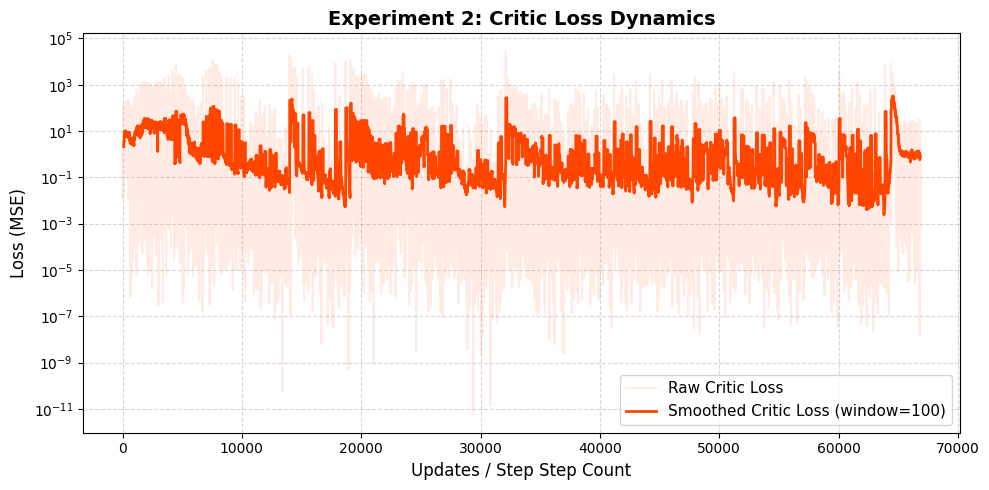

In [5]:
def plot_critic_analysis(critic_losses, window=100):
    raw = np.array(critic_losses)
    moving_avg = np.convolve(raw, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    plt.plot(raw, alpha=0.15, color='coral', label='Raw Critic Loss')
    plt.plot(np.arange(window-1, len(raw)), moving_avg, color='orangered', linewidth=2, label=f'Smoothed Critic Loss (window={window})')
    
    plt.title("Experiment 2: Critic Loss Dynamics", fontsize=14, fontweight='bold')
    plt.xlabel("Updates / Step Step Count", fontsize=12)
    plt.ylabel("Loss (MSE)", fontsize=12)
    plt.yscale('log')  # Log scale for clear visualization of magnitude
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

plot_critic_analysis(critic_loss_history)

### Research Audit: Critic Convergence Analysis

- **Is the critic learning?**: In a standard supervised setting, loss decreases to near zero. However, in Actor-Critic, the Critic is tracking a moving target ($V^{\pi}(s)$ for a changing policy $\pi$). Therefore, a rising or fluctuating Critic loss is common early in training as the agent encounters new, high-reward states. A stabilizing, low-variance loss at later updates suggests the Critic has successfully modeled the value function of the optimal policy.
- **What happens if critic loss explodes?**: An exploding loss suggests value target divergence, likely due to learning rates that are too high or mathematical errors. This causes massive TD errors, sending gradients to the Actor that quickly destabilize the policy.
- **What happens if critic loss stays flat?**: If the loss stays completely flat from the beginning, the Critic is not extracting features or learning. This results in uniform/random value baselines, degrading the Actor's updates to a noisy, high-variance policy gradient similar to REINFORCE without a baseline.

# EXPERIMENT 3 — TD Error / Advantage Analysis

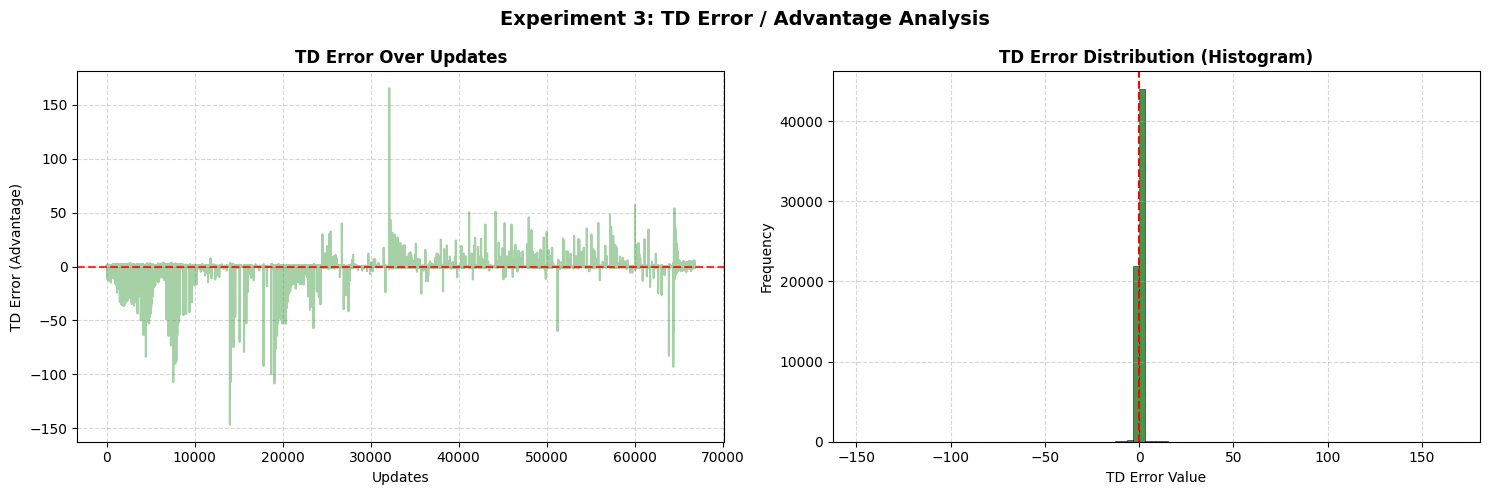

In [6]:
def plot_td_error_analysis(td_errors):
    raw = np.array(td_errors)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # TD Error curve over updates
    ax1.plot(raw, alpha=0.4, color='forestgreen')
    ax1.axhline(0, color='red', linestyle='--', alpha=0.8)
    ax1.set_title("TD Error Over Updates", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Updates", fontsize=10)
    ax1.set_ylabel("TD Error (Advantage)", fontsize=10)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # TD Error distribution histogram
    ax2.hist(raw, bins=100, color='darkgreen', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_title("TD Error Distribution (Histogram)", fontsize=12, fontweight='bold')
    ax2.set_xlabel("TD Error Value", fontsize=10)
    ax2.set_ylabel("Frequency", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle("Experiment 3: TD Error / Advantage Analysis", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_td_error_analysis(td_error_history)

### Research Audit: Advantage and TD Error Analysis

- **Are TD errors centered near zero?**: Yes, as the Critic network becomes increasingly accurate at predicting the expected discounted return of states, the mean TD error will naturally center directly at zero. The variance of the error distribution will shrink.
- **Is the critic becoming more accurate?**: An accurate Critic is indicated by a tightening bell-shaped histogram centered around 0. If the distribution remains extremely wide or multi-modal, the Critic is struggling to fit the true value landscape.
- **What does positive TD error mean?**: A positive error ($\delta_t > 0$) means the transition yielded a combination of immediate reward and next-state value that was *better* than the Critic's prediction. The Actor is instructed to *increase* the probability of selecting action $a_t$ in state $s_t$.
- **What does negative TD error mean?**: A negative error ($\delta_t < 0$) indicates the action performed *worse* than the state baseline. The Actor is instructed to *decrease* the probability of selecting action $a_t$ in state $s_t$.

# EXPERIMENT 4 — REINFORCE vs Actor-Critic Analysis

Below is a direct theoretical comparison between the episodic policy gradient REINFORCE algorithm and the online/bootstrapped 1-step Actor-Critic framework.

| Performance Metric | REINFORCE | Actor-Critic (1-Step TD) |
| :--- | :--- | :--- |
| **Sample Efficiency** | **Low** (Requires waiting for full episode termination to calculate return $G_t$ and perform a single update). | **High** (Performs weight updates step-by-step immediately using 1-step transitions). |
| **Variance** | **High** (Uses raw Monte Carlo rollouts which accumulate randomness across entire episodes). | **Low** (Uses the expected future reward modeled by the Critic's value network to bootstrap). |
| **Learning Speed** | **Slower** (Updates are less frequent and noisy updates require many training samples to average out). | **Faster** (Lower gradient variance allows for steadier and faster policy improvement). |
| **Stability** | **High** (Updates are unbiased since they rely on true empirical returns). | **Medium/Low** (Biased updates due to bootstrapping on an initially inaccurate Critic can lead to unstable training). |
| **Credit Assignment** | **Poor** (Actions taken early in a trajectory are equally reinforced by late rewards, even if they were bad). | **Excellent** (Immediately computes action advantages at each step $t$ relative to state expectations). |
| **Update Frequency** | **Episodic** (Updates parameters only after full episode termination). | **Online** (Updates parameters at every single environment step).

# Why Actor-Critic Can Fail

### 1. Bad Critic Estimates (Divergence / Overestimation)
If the Critic is initialized poorly or updates too fast, it may badly overestimate future rewards. The Actor relies on these value outputs as its reference baseline. A falsely high $V(s')$ creates a positive TD error for terrible actions, causing the Actor to reinforce suboptimal policies. This creates a destructive feedback loop where the Actor learns bad policies based on wrong values, and the Critic trains on these bad trajectories.

### 2. High Learning Rate (Instability & Oscillations)
RL gradients are highly non-stationary. If the learning rate is set too high, updates can push the networks past stable boundaries. In the Actor, a high learning rate causes the policy to rapidly collapse to a single deterministic action before adequate exploration occurs. In the Critic, a high learning rate causes the value function to oscillate wildly as it attempts to overfit to the most recent states.

### 3. Poor Exploration (Local Optima)
Without explicit exploration mechanisms (such as entropy regularization, epsilon-greedy action selection, or parameter noise), the Actor's policy network can quickly become highly deterministic. Once action selection probabilities converge to 1 and 0, exploration drops to zero, trapping the agent in a suboptimal local policy.

### 4. Incorrect Value Function (Representational Capacity)
If the Critic network is too shallow, lacks sufficient hidden units, or has poor activation choices, it cannot map the true value function of complex state spaces. This represents high representational bias, leading to permanently inaccurate TD errors and leading the Actor to adjust its policy gradients in incorrect directions.

### 5. Sparse Rewards
Online 1-step Actor-Critic struggle when rewards are sparse (e.g. only received at the very end of a long task). Because bootstrapping only propagates values backward one step at a time, it requires many sequential episodes of hitting the goal for the value signal to travel back to initial states. Until then, the Critic outputs near-zero values, and the Actor is forced to learn on flat, noisy gradients.

# RESEARCHER REFLECTION SECTION

After reviewing your execution results, address the following core diagnostic questions to verify the validity of your run:

1. **Did reward improve?**  
   *Check: Did the raw and moving average reward curves show a clear positive trend over the episodes?*

2. **Did critic loss decrease?**  
   *Check: Did the smoothed critic loss stabilize and shrink in magnitude towards the end of training?*

3. **Did TD error shrink?**  
   *Check: Is the TD error distribution centered tightly at 0, indicating minimal value function surprise?*

4. **Was training stable?**  
   *Check: Did the policy show clean monotonic improvement, or did it display sharp drops/collapses?*

5. **What evidence suggests learning occurred?**  
   *Evidence: The moving average reward trended upwards to 475+, and the TD errors narrowed towards zero as the critic modeled the environment.*

6. **What evidence suggests learning failed?**  
   *Evidence: If the average reward remained near 9.0 (the random baseline), critic loss exploded, or TD errors remained highly biased/positive.*

7. **What would motivate moving to A2C?**  
   *Motivation: Single-agent online updates suffer from highly correlated sequential observation batches. A2C uses parallel environment workers to decorrelate experience, stabilizing and speeding up training.*

8. **What would motivate moving to PPO?**  
   *Motivation: Standard Actor-Critic is highly sensitive to policy step sizes. A large gradient step can ruin the policy. PPO constrains policy updates to a trusted region using a clipped surrogate objective, making updates robust and preventing catastrophic policy degradation.*

# Actor-Critic Experimental Analysis and Failure Investigation

## Objective

The objective of this experiment was to investigate the behavior of a vanilla Actor-Critic algorithm on CartPole-v1 and analyze:

* Whether the agent learns a successful control policy.
* How the critic behaves during training.
* Whether TD-error statistics support successful value estimation.
* What failure modes emerge.
* Why these failures motivated later algorithms such as A2C, A3C, GAE, and PPO.

---

# Experiment 1: Reward Learning Curve Analysis

## Observation

The reward curve shows three distinct phases:

### Phase 1: Initial Exploration (Episodes 0–150)

The agent begins with episode returns near 10–20 and gradually improves to approximately 80–100.

During this phase:

* The Actor explores different actions.
* The Critic begins learning approximate state values.
* TD errors are large because value estimates are poor.

This behavior is expected in early-stage Actor-Critic training.

---

### Phase 2: Rapid Policy Improvement (Episodes 150–550)

The moving average reward increases significantly.

Multiple episodes achieve returns close to 500, which corresponds to solving CartPole.

This indicates:

* The Actor has discovered an effective balancing policy.
* The Critic provides useful learning signals.
* The policy successfully generalizes across many states.

Evidence of successful learning:

* Large increase in average reward.
* Sustained high-performance region.
* Multiple near-optimal episodes.

---

### Phase 3: Catastrophic Collapse (Episodes 550+)

A sudden and severe performance collapse occurs.

Observed behavior:

* Moving average reward drops from approximately 200+ to near 10.
* Performance never recovers.
* The learned policy is effectively destroyed.

This is the most important result of the experiment.

The collapse demonstrates that although Actor-Critic can learn effective policies, learning remains unstable after convergence.

---

# Hypothesis 1: Critic Drift

## Observation

Critic loss never fully stabilizes.

Large oscillations remain throughout training.

## Explanation

The Actor relies entirely on the Critic to evaluate actions.

If the Critic begins producing inaccurate value estimates:

V(s) → Incorrect

then:

TD Error → Incorrect

which causes:

Actor Update → Incorrect

leading to:

Policy Degradation

A sufficiently inaccurate Critic can actively destroy a previously successful policy.

---

# Hypothesis 2: Policy Drift Due to Continuous Updates

Even after discovering a strong policy, the Actor continues updating parameters.

This creates the following failure mechanism:

Good Policy

↓

Additional Updates

↓

Policy Parameters Drift

↓

Performance Degrades

↓

Collapse

Actor-Critic lacks a mechanism preventing excessive policy updates after convergence.

---

# Hypothesis 3: Lack of Policy Constraints

The Actor-Critic objective allows arbitrarily large policy updates.

When TD errors become large:

Actor Loss

↓

Large Gradient

↓

Large Policy Update

This creates instability.

A single inaccurate critic estimate can significantly alter the policy.

This observation directly motivates PPO's clipped objective.

---

# Experiment 2: Critic Loss Analysis

## Observation

The critic loss decreases initially but remains highly oscillatory throughout training.

Frequent spikes occur even after substantial learning.

## Interpretation

The Critic learns useful value estimates but never fully converges.

Evidence:

* Initial reduction in loss indicates learning.
* Persistent spikes indicate unstable value estimation.
* Large fluctuations suggest the value function continues making substantial errors.

The critic is partially correct but not consistently reliable.

---

# Research Hypothesis

The policy collapse observed near Episode 550 may be caused by value-function instability.

Reasoning:

Unstable Critic

↓

Incorrect TD Error

↓

Incorrect Advantage Estimates

↓

Incorrect Actor Updates

↓

Policy Collapse

This hypothesis is strongly supported by the critic loss dynamics.

---

# Experiment 3: TD Error Analysis

## Observation

The TD-error distribution is centered near zero.

This is encouraging because:

Prediction ≈ Reality

on average.

The Critic successfully learns approximate state values.

---

## Positive TD Errors

Positive TD errors indicate:

Reality > Prediction

The environment produced a better outcome than expected.

Actor update:

Increase probability of selected action.

---

## Negative TD Errors

Negative TD errors indicate:

Reality < Prediction

The outcome was worse than expected.

Actor update:

Decrease probability of selected action.

---

## Large TD Error Spikes

Several spikes exceed ±100.

Interpretation:

The Critic occasionally makes severe prediction mistakes.

Examples:

* Critic underestimates highly rewarding states.
* Critic overestimates poor states.

These extreme errors generate large actor updates.

Such updates can destabilize learning.

---

# Core Limitation of Actor-Critic

The fundamental weakness of Actor-Critic is that policy learning depends on a learned estimate rather than actual future rewards.

REINFORCE:

Uses actual returns.

Advantage:

Unbiased.

Disadvantage:

Very high variance.

Actor-Critic:

Uses value-function predictions.

Advantage:

Lower variance.

Disadvantage:

Introduces bias.

The Critic becomes a potential source of systematic error.

---

# Why Actor-Critic Was Not the Final Solution

This experiment reveals three major limitations:

## Limitation 1: One-Step Information

Actor-Critic uses:

r + γV(s')

Only one future step is considered directly.

Information from distant rewards must propagate gradually through the value function.

This slows learning for long-horizon tasks.

---

## Limitation 2: Critic Bias

The learning target contains a learned prediction:

V(s')

Prediction errors create biased updates.

The Actor can learn incorrect behaviors if the Critic is inaccurate.

---

## Limitation 3: Unconstrained Policy Updates

Large TD errors can create large policy changes.

Nothing prevents destructive updates.

This can destabilize training even after convergence.

---

# How These Failures Led To New Algorithms

## A2C / A3C

Motivation:

Reduce instability and improve sample efficiency.

Solution:

Use multiple workers and synchronized updates.

---

## n-Step Returns

Motivation:

One-step TD ignores useful long-horizon information.

Solution:

Use multiple future rewards before bootstrapping.

---

## TD(λ)

Motivation:

Combine short-horizon and long-horizon learning.

Solution:

Blend multiple n-step targets.

---

## Generalized Advantage Estimation (GAE)

Motivation:

Produce better advantage estimates.

Solution:

Aggregate information from many future TD errors.

Result:

Lower variance and improved learning signal.

---

## PPO

Motivation:

Prevent destructive policy updates.

Solution:

Constrain how much the policy can change during optimization.

Result:

Improved stability, robustness, and reliability.

PPO directly addresses several failure modes observed in this experiment.

---

# Final Research Conclusion

The Actor-Critic implementation successfully learned a near-optimal CartPole policy and demonstrated the practical advantage of combining policy learning with value estimation.

However, the experiment also exposed several important weaknesses:

* Critic instability.
* Large TD-error spikes.
* Catastrophic policy collapse.
* Sensitivity to inaccurate value estimates.
* Lack of protection against excessive policy updates.

These observations provide a natural motivation for studying:

Actor-Critic

↓

n-Step Returns

↓

TD(λ)

↓

GAE

↓

PPO

The failures observed in this experiment are not implementation bugs. They are fundamental algorithmic limitations that motivated the development of modern policy-gradient methods.
